In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

R = 8.314  # J mol^-1 K^-1

Final_code_for_p1

In [4]:
# =========================
# LOAD DATA
# =========================
file_name = "MAgnetic_data_P1.csv"   # change this

df = pd.read_csv(file_name)
df.columns = df.columns.str.strip()

print(df.columns)
print(df.head())

Index(['Temperature (K)', 'Chi (Molar)* T'], dtype='str')
   Temperature (K)  Chi (Molar)* T
0        299.99054         1.01056
1        299.93100         1.00790
2        298.83998         1.00789
3        297.77979         1.00472
4        296.85161         1.00649


In [5]:
# =========================
# PICK COLUMNS
# =========================
T_all = df["Temperature (K)"].values
chiT_all = df["Chi (Molar)* T"].values   # change column name if needed

mask = np.isfinite(T_all) & np.isfinite(chiT_all)
T_all = T_all[mask]
chiT_all = chiT_all[mask]

# ---------------------------------------
# Split cooling / heating at minimum T
# ---------------------------------------
imin = np.argmin(T_all)

T_cool = T_all[:imin+1]
chiT_cool = chiT_all[:imin+1]

T_heat = T_all[imin:]
chiT_heat = chiT_all[imin:]

# Sort each branch
idxc = np.argsort(T_cool)
T_cool = T_cool[idxc]
chiT_cool = chiT_cool[idxc]

idxh = np.argsort(T_heat)
T_heat = T_heat[idxh]
chiT_heat = chiT_heat[idxh]

print("Cooling points:", len(T_cool))
print("Heating points:", len(T_heat))
print("Cooling T range:", T_cool.min(), "to", T_cool.max())
print("Heating T range:", T_heat.min(), "to", T_heat.max())

Cooling points: 280
Heating points: 297
Cooling T range: 5.00122 to 299.99054
Heating T range: 5.00122 to 299.8761


In [6]:
# =========================
# AUTO PLATEAU ESTIMATION
# =========================
def estimate_plateaus(T, chiT, frac=0.12):
    n = len(T)
    k = max(5, int(frac * n))
    chi_ls = np.mean(chiT[:k])     # low-T plateau
    chi_hs = np.mean(chiT[-k:])    # high-T plateau
    return chi_ls, chi_hs

chiLS_heat, chiHS_heat = estimate_plateaus(T_heat, chiT_heat)
chiLS_cool, chiHS_cool = estimate_plateaus(T_cool, chiT_cool)

print("Heating LS plateau χT =", chiLS_heat)
print("Heating HS plateau χT =", chiHS_heat)
print("Cooling LS plateau χT =", chiLS_cool)
print("Cooling HS plateau χT =", chiHS_cool)

Heating LS plateau χT = 0.14118885714285717
Heating HS plateau χT = 0.9937417142857143
Cooling LS plateau χT = 0.17493151515151512
Cooling HS plateau χT = 0.996689696969697


In [7]:
# =========================
# TWO-STEP SD MODEL
# =========================
def solve_sd_fraction(T, dH, dS, Gamma, gamma0=0.5, max_iter=500, tol=1e-10):
    """
    Self-consistent Slichter-Drickamer equation:
    gamma = 1 / [1 + exp((dH - T*dS + Gamma*(1 - 2*gamma)) / (R*T))]
    """
    T = np.asarray(T, dtype=float)
    gamma = np.full_like(T, gamma0, dtype=float)

    for _ in range(max_iter):
        expo = (dH - T*dS + Gamma*(1.0 - 2.0*gamma)) / (R*T)
        expo = np.clip(expo, -700, 700)
        gamma_new = 1.0 / (1.0 + np.exp(expo))

        if np.max(np.abs(gamma_new - gamma)) < tol:
            return gamma_new

        gamma = gamma_new

    return gamma


def two_step_sd_model(T, params):
    """
    params = [
        dH1, dS1, G1,
        dH2, dS2, G2,
        w,
        chiLS0, beta,
        chiHS0, alpha
    ]

    chi_LS(T) = chiLS0 + beta*T
    chi_HS(T) = chiHS0 + alpha*T
    """
    dH1, dS1, G1, dH2, dS2, G2, w, chiLS0, beta, chiHS0, alpha = params

    g1 = solve_sd_fraction(T, dH1, dS1, G1, gamma0=0.01)
    g2 = solve_sd_fraction(T, dH2, dS2, G2, gamma0=0.99)

    gamma_tot = w * g1 + (1.0 - w) * g2

    chi_ls_T = chiLS0 + beta * T
    chi_hs_T = chiHS0 + alpha * T

    chiT_calc = (1.0 - gamma_tot) * chi_ls_T + gamma_tot * chi_hs_T
    return chiT_calc, gamma_tot, g1, g2

In [8]:
# =========================
# FITTING SETUP
# =========================
def residuals_two_step(params, T, chiT_exp):
    chiT_calc, gamma_tot, g1, g2 = two_step_sd_model(T, params)
    return chiT_calc - chiT_exp


def initial_guess(T, chiT, chiLS_guess, chiHS_guess):
    # Rough thermodynamic starting values
    # dH in J/mol, dS in J/mol/K, Gamma in J/mol
    return np.array([
        12000.0, 80.0, 1500.0,   # step 1
        9000.0,  70.0,  800.0,   # step 2
        0.5,                     # weight
        chiLS_guess, 0.0,        # LS baseline
        chiHS_guess, 0.0         # HS baseline
    ])


lower_bounds = [
    1000.0,   1.0,   -10000.0,
    1000.0,   1.0,   -10000.0,
    0.0,
    -10.0,   -1.0,
    -10.0,   -1.0
]

upper_bounds = [
    50000.0, 300.0,  10000.0,
    50000.0, 300.0,  10000.0,
    1.0,
    20.0,     1.0,
    20.0,     1.0
]

In [9]:
# =========================
# FIT HEATING
# =========================
p0_heat = initial_guess(T_heat, chiT_heat, chiLS_heat, chiHS_heat)

fit_heat = least_squares(
    residuals_two_step,
    p0_heat,
    bounds=(lower_bounds, upper_bounds),
    args=(T_heat, chiT_heat),
    max_nfev=3000
)

params_heat = fit_heat.x
chiT_fit_heat, gamma_heat, g1_heat, g2_heat = two_step_sd_model(T_heat, params_heat)

print("Heating fit success:", fit_heat.success)
print("Heating message:", fit_heat.message)
print("\nHeating parameters:")
names = [
    "dH1", "dS1", "G1",
    "dH2", "dS2", "G2",
    "w",
    "chiLS0", "beta",
    "chiHS0", "alpha"
]
for n, v in zip(names, params_heat):
    print(f"{n:8s} = {v:.6f}")

Heating fit success: True
Heating message: `ftol` termination condition is satisfied.

Heating parameters:
dH1      = 8169.696667
dS1      = 56.321278
G1       = 2131.781725
dH2      = 22312.973389
dS2      = 213.997697
G2       = 57.523904
w        = 0.644319
chiLS0   = 0.108625
beta     = 0.001609
chiHS0   = 0.748312
alpha    = 0.000879


In [10]:
# =========================
# FIT COOLING
# =========================
p0_cool = initial_guess(T_cool, chiT_cool, chiLS_cool, chiHS_cool)

fit_cool = least_squares(
    residuals_two_step,
    p0_cool,
    bounds=(lower_bounds, upper_bounds),
    args=(T_cool, chiT_cool),
    max_nfev=3000
)

params_cool = fit_cool.x
chiT_fit_cool, gamma_cool, g1_cool, g2_cool = two_step_sd_model(T_cool, params_cool)

print("Cooling fit success:", fit_cool.success)
print("Cooling message:", fit_cool.message)
print("\nCooling parameters:")
for n, v in zip(names, params_cool):
    print(f"{n:8s} = {v:.6f}")

Cooling fit success: True
Cooling message: `ftol` termination condition is satisfied.

Cooling parameters:
dH1      = 10511.790415
dS1      = 72.380925
G1       = 1935.337986
dH2      = 12033.952338
dS2      = 133.841950
G2       = 117.582623
w        = 0.651002
chiLS0   = 0.107290
beta     = 0.001788
chiHS0   = 0.740739
alpha    = 0.000906


In [11]:
# =========================
# FIT QUALITY METRICS
# =========================

def fit_statistics(y_exp, y_fit):

    residuals = y_exp - y_fit

    rmse = np.sqrt(np.mean(residuals**2))

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_exp - np.mean(y_exp))**2)

    r2 = 1 - ss_res/ss_tot

    return rmse, r2, residuals


# Heating statistics
rmse_heat, r2_heat, res_heat = fit_statistics(chiT_heat, chiT_fit_heat)

# Cooling statistics
rmse_cool, r2_cool, res_cool = fit_statistics(chiT_cool, chiT_fit_cool)


print("===== FIT QUALITY =====")
print(f"Heating RMSE = {rmse_heat:.6f}")
print(f"Heating R²   = {r2_heat:.6f}")

print()

print(f"Cooling RMSE = {rmse_cool:.6f}")
print(f"Cooling R²   = {r2_cool:.6f}")

===== FIT QUALITY =====
Heating RMSE = 0.005431
Heating R²   = 0.999739

Cooling RMSE = 0.003049
Cooling R²   = 0.999904


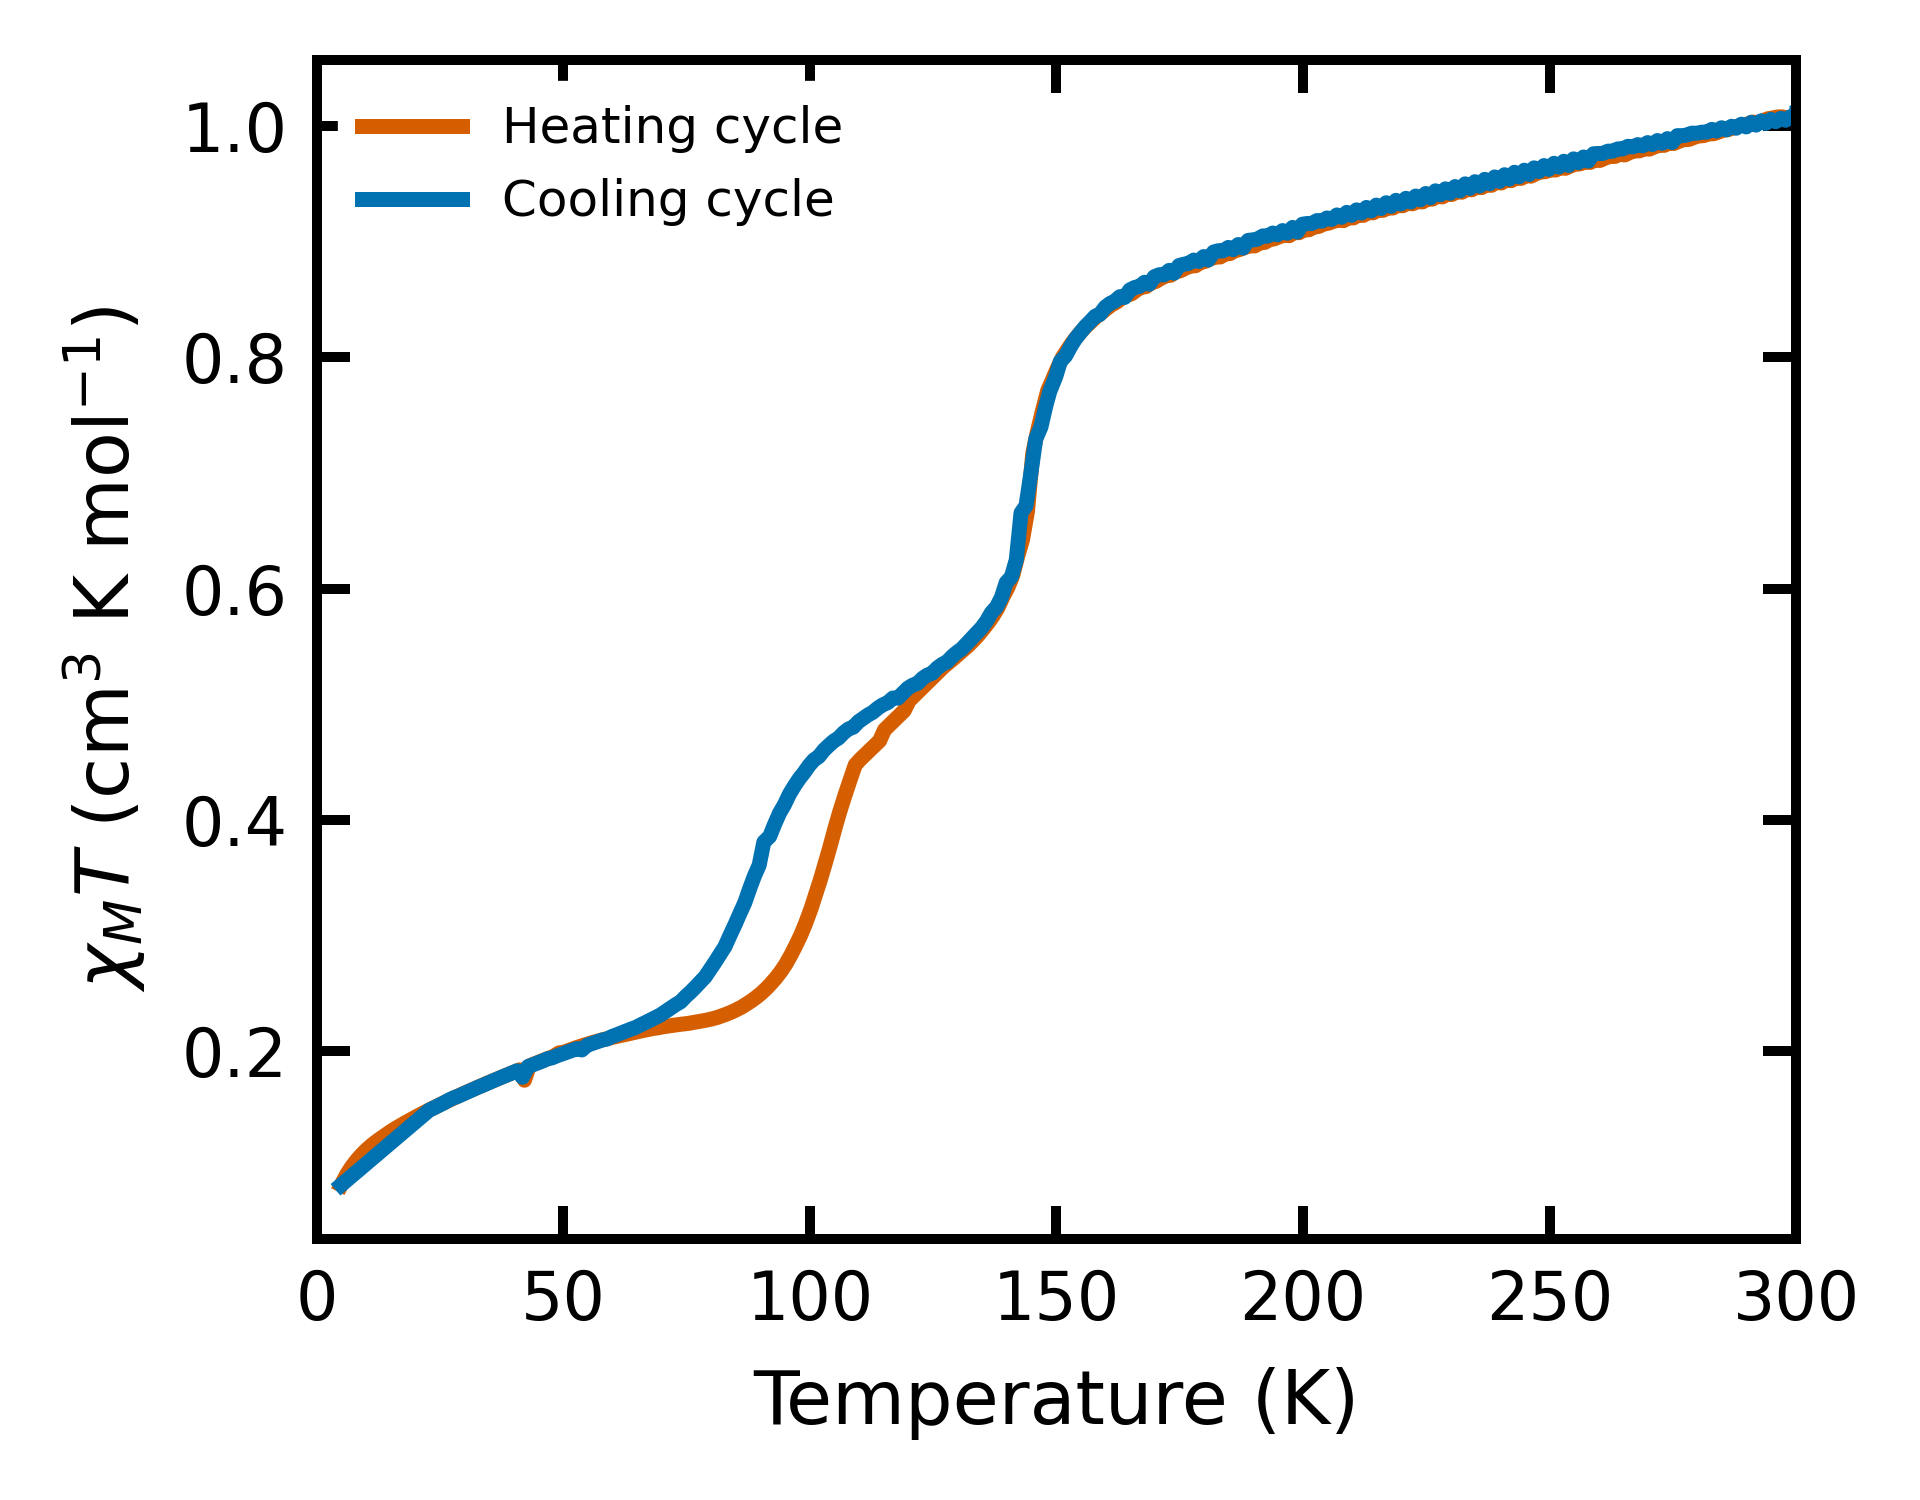

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(3.3, 2.6), dpi=600)
ax = plt.gca()

# Solid lines only
ax.plot(T_heat, chiT_heat, color='#D55E00', lw=1.8, label='Heating cycle')
ax.plot(T_cool, chiT_cool, color='#0072B2', lw=1.8, label='Cooling cycle')

ax.set_xlabel("Temperature (K)", fontsize=9)
ax.set_ylabel(r'$\chi_M T$ (cm$^3$ K mol$^{-1}$)', fontsize=9)

# Fixed x-axis scale (same as other figure)
ax.set_xlim(0, 300)
ax.set_xticks(np.arange(0, 301, 50))

# Tick styling
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=4,
    width=1.2,
    labelsize=8,
    top=True,
    right=True
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=2,
    width=1.0,
    top=False,
    right=False
)

#ax.minorticks_on()

# Spine styling
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# Legend (top-right, clean)
ax.legend(
    fontsize=6,
    loc='upper left',
    frameon=True,
    edgecolor='white',   # same as your reference style
    fancybox=False,
    framealpha=1.0
)

plt.tight_layout()
plt.savefig("chiT_vs_T_solid.tiff", dpi=600, bbox_inches='tight')
plt.savefig("chiT_vs_T_solid.png", dpi=600, bbox_inches='tight')
plt.show()

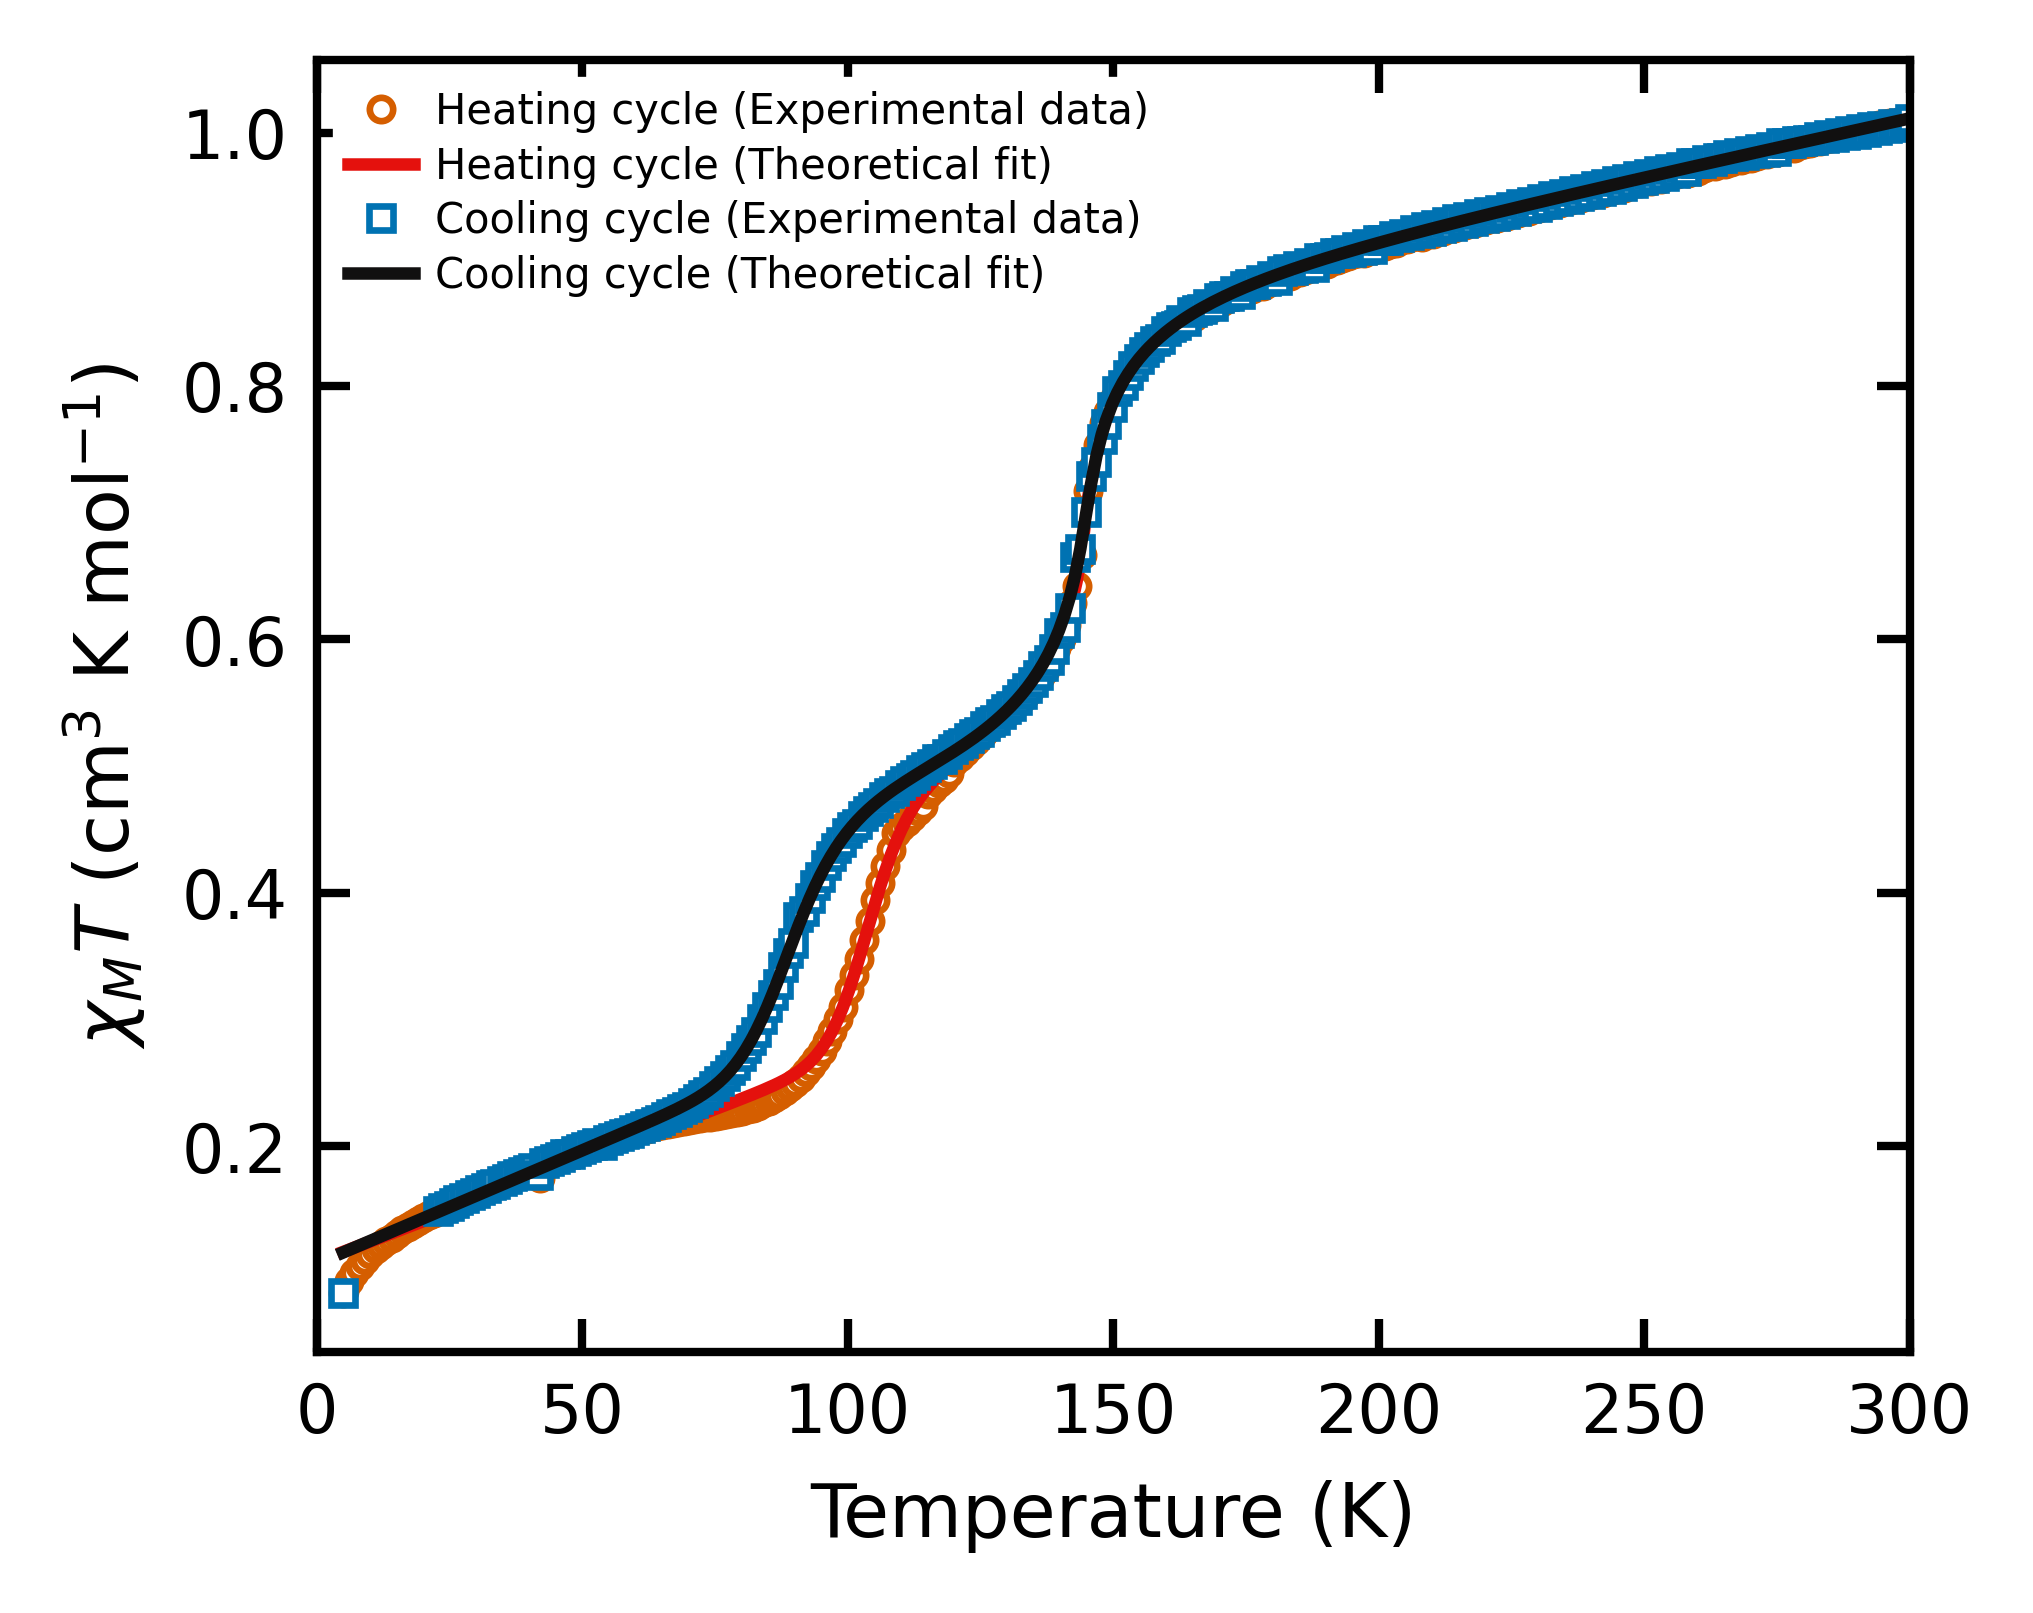

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# JPCC-style figure
# -----------------------------
plt.figure(figsize=(3.3, 2.6), dpi=600)
ax = plt.gca()

# Heating branch
ax.plot(
    T_heat, chiT_heat,
    linestyle='None',
    marker='o',
    markersize=2.8,
    markerfacecolor='white',
    markeredgewidth=0.8,
    color='#D55E00',
    label='Heating cycle (Experimental data)'
)
ax.plot(
    T_heat, chiT_fit_heat,
    linestyle='-',
    linewidth=1.5,
    color="#E4110DFF",
    label='Heating cycle (Theoretical fit)'
)

# Cooling branch
ax.plot(
    T_cool, chiT_cool,
    linestyle='None',
    marker='s',
    markersize=2.8,
    markerfacecolor='white',
    markeredgewidth=0.8,
    color='#0072B2',
    label='Cooling cycle (Experimental data)'
)
ax.plot(
    T_cool, chiT_fit_cool,
    linestyle='-',
    linewidth=1.5,
    color="#111010",
    label='Cooling cycle (Theoretical fit)'
)

# Labels
ax.set_xlabel("Temperature (K)", fontsize=9)
ax.set_ylabel(r'$\chi_M T$ (cm$^3$ K mol$^{-1}$)', fontsize=9)

# Fixed axis scale for consistency
ax.set_xlim(0, 300)
ax.set_xticks(np.arange(0, 301, 50))

# Tick styling
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=4,
    width=1.0,
    labelsize=8,
    top=True,
    right=True
)
ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=2,
    width=0.8,
    top=False,
    right=False
)
#ax.minorticks_on()

# Borderlines
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Legend
ax.legend(
    fontsize=5,
    loc='upper left',
    frameon=True,
    edgecolor='white',
    fancybox=False,
    framealpha=1.0,
    borderpad=0.25,
    handlelength=1.6,
    handletextpad=0.5,
    labelspacing=0.3
)

# Margins
ax.margins(x=0.02, y=0.05)

plt.tight_layout(pad=0.4)
plt.savefig("chiMT_fit_JPCC.tiff", dpi=600, bbox_inches='tight')
plt.savefig("chiMT_fit_JPCC.png", dpi=600, bbox_inches='tight')
plt.show()

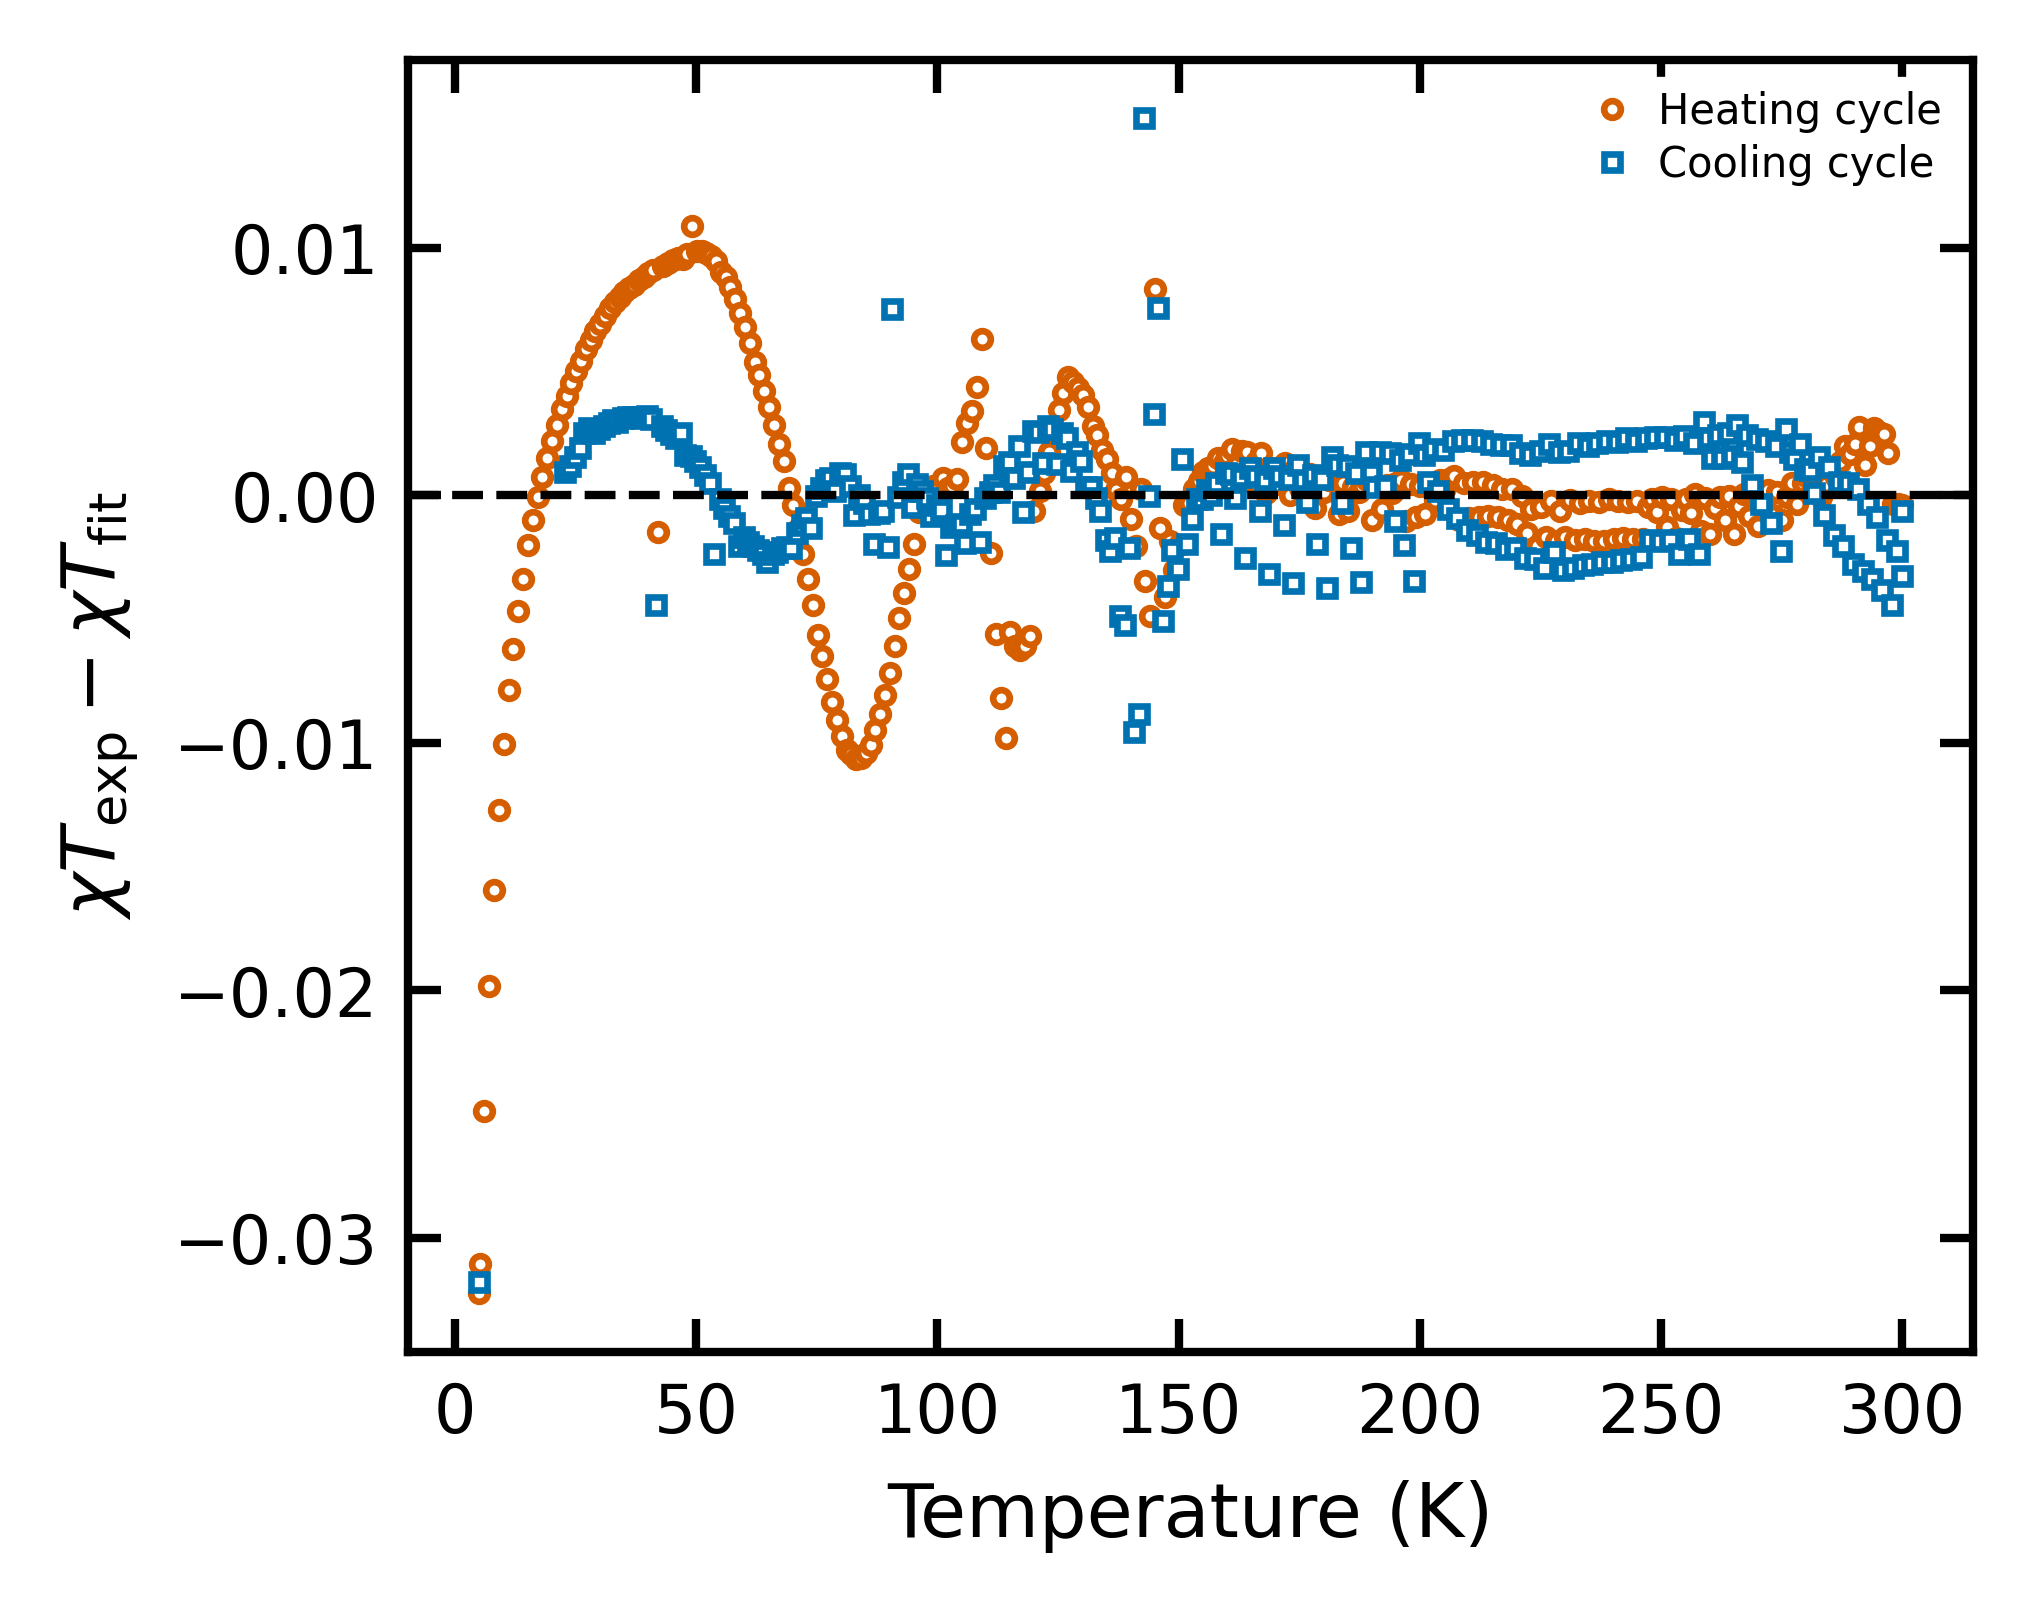

In [16]:
# =========================
# PUBLICATION-QUALITY RESIDUAL PLOT (JPCC-TIGHTENED)
# =========================
fig, ax = plt.subplots(figsize=(3.3, 2.6), dpi=600)

# Heating residuals
ax.plot(
    T_heat, res_heat,
    linestyle='None',
    marker='o',
    markersize=2,
    markerfacecolor='white',
    markeredgewidth=0.8,
    color='#D55E00',
    label='Heating cycle'
)

# Cooling residuals
ax.plot(
    T_cool, res_cool,
    linestyle='None',
    marker='s',
    markersize=2,
    markerfacecolor='white',
    markeredgewidth=0.8,
    color='#0072B2',
    label='Cooling cycle'
)

# Zero reference line
ax.axhline(
    0,
    color='black',
    linewidth=1.0,
    linestyle='--'
)

# Axis labels
ax.set_xlabel("Temperature (K)", fontsize=9)
ax.set_ylabel(r'$\chi T_{\mathrm{exp}} - \chi T_{\mathrm{fit}}$', fontsize=9)

# Major ticks (all sides)
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=4,
    width=1.0,
    labelsize=8,
    top=True,
    right=True
)

# Minor ticks (bottom + left only)
ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=2,
    width=0.8,
    top=False,
    right=False
)
# ax.minorticks_on()

# Spine styling
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Legend (compact JPCC style)
ax.legend(
    fontsize=5,
    loc='upper right',
    frameon=True,
    edgecolor='white',
    fancybox=False,
    framealpha=1.0,
    borderpad=0.25,
    handlelength=1.4,
    handletextpad=0.4,
    labelspacing=0.25
)

# Tight layout
plt.tight_layout(pad=0.4)

# Save
plt.savefig("Residuals_publishable.png", dpi=600, bbox_inches='tight')
plt.savefig("Residuals_publishable.tiff", dpi=600, bbox_inches='tight')

plt.show()

In [17]:
# =========================
# BOOTSTRAP PARAMETER UNCERTAINTY
# =========================

n_boot = 200
boot_params = []

rng = np.random.default_rng()

for i in range(n_boot):

    # resample indices
    idx = rng.integers(0, len(T_heat), len(T_heat))

    T_boot = T_heat[idx]
    chi_boot = chiT_heat[idx]

    try:

        fit_boot = least_squares(
            residuals_two_step,
            params_heat,
            bounds=(lower_bounds, upper_bounds),
            args=(T_boot, chi_boot),
            max_nfev=2000
        )

        boot_params.append(fit_boot.x)

    except:
        pass


boot_params = np.array(boot_params)

param_std = np.std(boot_params, axis=0)

print("\n===== PARAMETER UNCERTAINTY (Bootstrap) =====")

for name, val, err in zip(names, params_heat, param_std):
    print(f"{name:8s} = {val:.3f} ± {err:.3f}")


===== PARAMETER UNCERTAINTY (Bootstrap) =====
dH1      = 8169.697 ± 654.660
dS1      = 56.321 ± 4.521
G1       = 2131.782 ± 32.736
dH2      = 22312.973 ± 2759.641
dS2      = 213.998 ± 26.286
G2       = 57.524 ± 264.311
w        = 0.644 ± 0.008
chiLS0   = 0.109 ± 0.003
beta     = 0.002 ± 0.000
chiHS0   = 0.748 ± 0.006
alpha    = 0.001 ± 0.000


In [28]:
# =========================
# TRANSITION ANALYSIS
# =========================
def find_two_transition_temperatures(T, gamma):
    dg = np.gradient(gamma, T)

    # Get indices of largest positive slopes
    idx_sorted = np.argsort(dg)[::-1]

    picked = []
    min_sep = max(5, int(0.08 * len(T)))  # avoid selecting same peak twice

    for idx in idx_sorted:
        if all(abs(idx - j) > min_sep for j in picked):
            picked.append(idx)
        if len(picked) == 2:
            break

    picked = sorted(picked)
    Tcs = [T[i] for i in picked]
    slopes = [dg[i] for i in picked]

    return Tcs, slopes, dg


Tcs_heat, slopes_heat, dg_heat = find_two_transition_temperatures(T_heat, gamma_heat)
Tcs_cool, slopes_cool, dg_cool = find_two_transition_temperatures(T_cool, gamma_cool)

print("Heating transition temperatures:", Tcs_heat)
print("Heating max slopes dγ/dT:", slopes_heat)

print("Cooling transition temperatures:", Tcs_cool)
print("Cooling max slopes dγ/dT:", slopes_cool)

Heating transition temperatures: [np.float64(104.12713), np.float64(145.1912)]
Heating max slopes dγ/dT: [np.float64(0.023085509409063357), np.float64(0.05813211729645695)]
Cooling transition temperatures: [np.float64(88.83323), np.float64(144.84763)]
Cooling max slopes dγ/dT: [np.float64(0.01717663293024746), np.float64(0.04796368021716935)]


In [29]:
# =========================
# COOPERATIVITY / DOMAIN-GROWTH SUMMARY
# =========================
def summarize_step_analysis(Tcs_heat, Tcs_cool, slopes_heat, slopes_cool):
    # assumes sorted in same order
    dT1 = Tcs_heat[0] - Tcs_cool[0]
    dT2 = Tcs_heat[1] - Tcs_cool[1]

    print("===== TRANSITION SUMMARY =====")
    print(f"Step 1: Heating Tc = {Tcs_heat[0]:.2f} K")
    print(f"        Cooling Tc = {Tcs_cool[0]:.2f} K")
    print(f"        Hysteresis width = {dT1:.2f} K")
    print(f"        Heating sharpness max(dγ/dT) = {slopes_heat[0]:.5f} K^-1")
    print(f"        Cooling sharpness max(dγ/dT) = {slopes_cool[0]:.5f} K^-1")
    print()

    print(f"Step 2: Heating Tc = {Tcs_heat[1]:.2f} K")
    print(f"        Cooling Tc = {Tcs_cool[1]:.2f} K")
    print(f"        Hysteresis width = {dT2:.2f} K")
    print(f"        Heating sharpness max(dγ/dT) = {slopes_heat[1]:.5f} K^-1")
    print(f"        Cooling sharpness max(dγ/dT) = {slopes_cool[1]:.5f} K^-1")
    print()

   

summarize_step_analysis(Tcs_heat, Tcs_cool, slopes_heat, slopes_cool)

===== TRANSITION SUMMARY =====
Step 1: Heating Tc = 104.13 K
        Cooling Tc = 88.83 K
        Hysteresis width = 15.29 K
        Heating sharpness max(dγ/dT) = 0.02309 K^-1
        Cooling sharpness max(dγ/dT) = 0.01718 K^-1

Step 2: Heating Tc = 145.19 K
        Cooling Tc = 144.85 K
        Hysteresis width = 0.34 K
        Heating sharpness max(dγ/dT) = 0.05813 K^-1
        Cooling sharpness max(dγ/dT) = 0.04796 K^-1



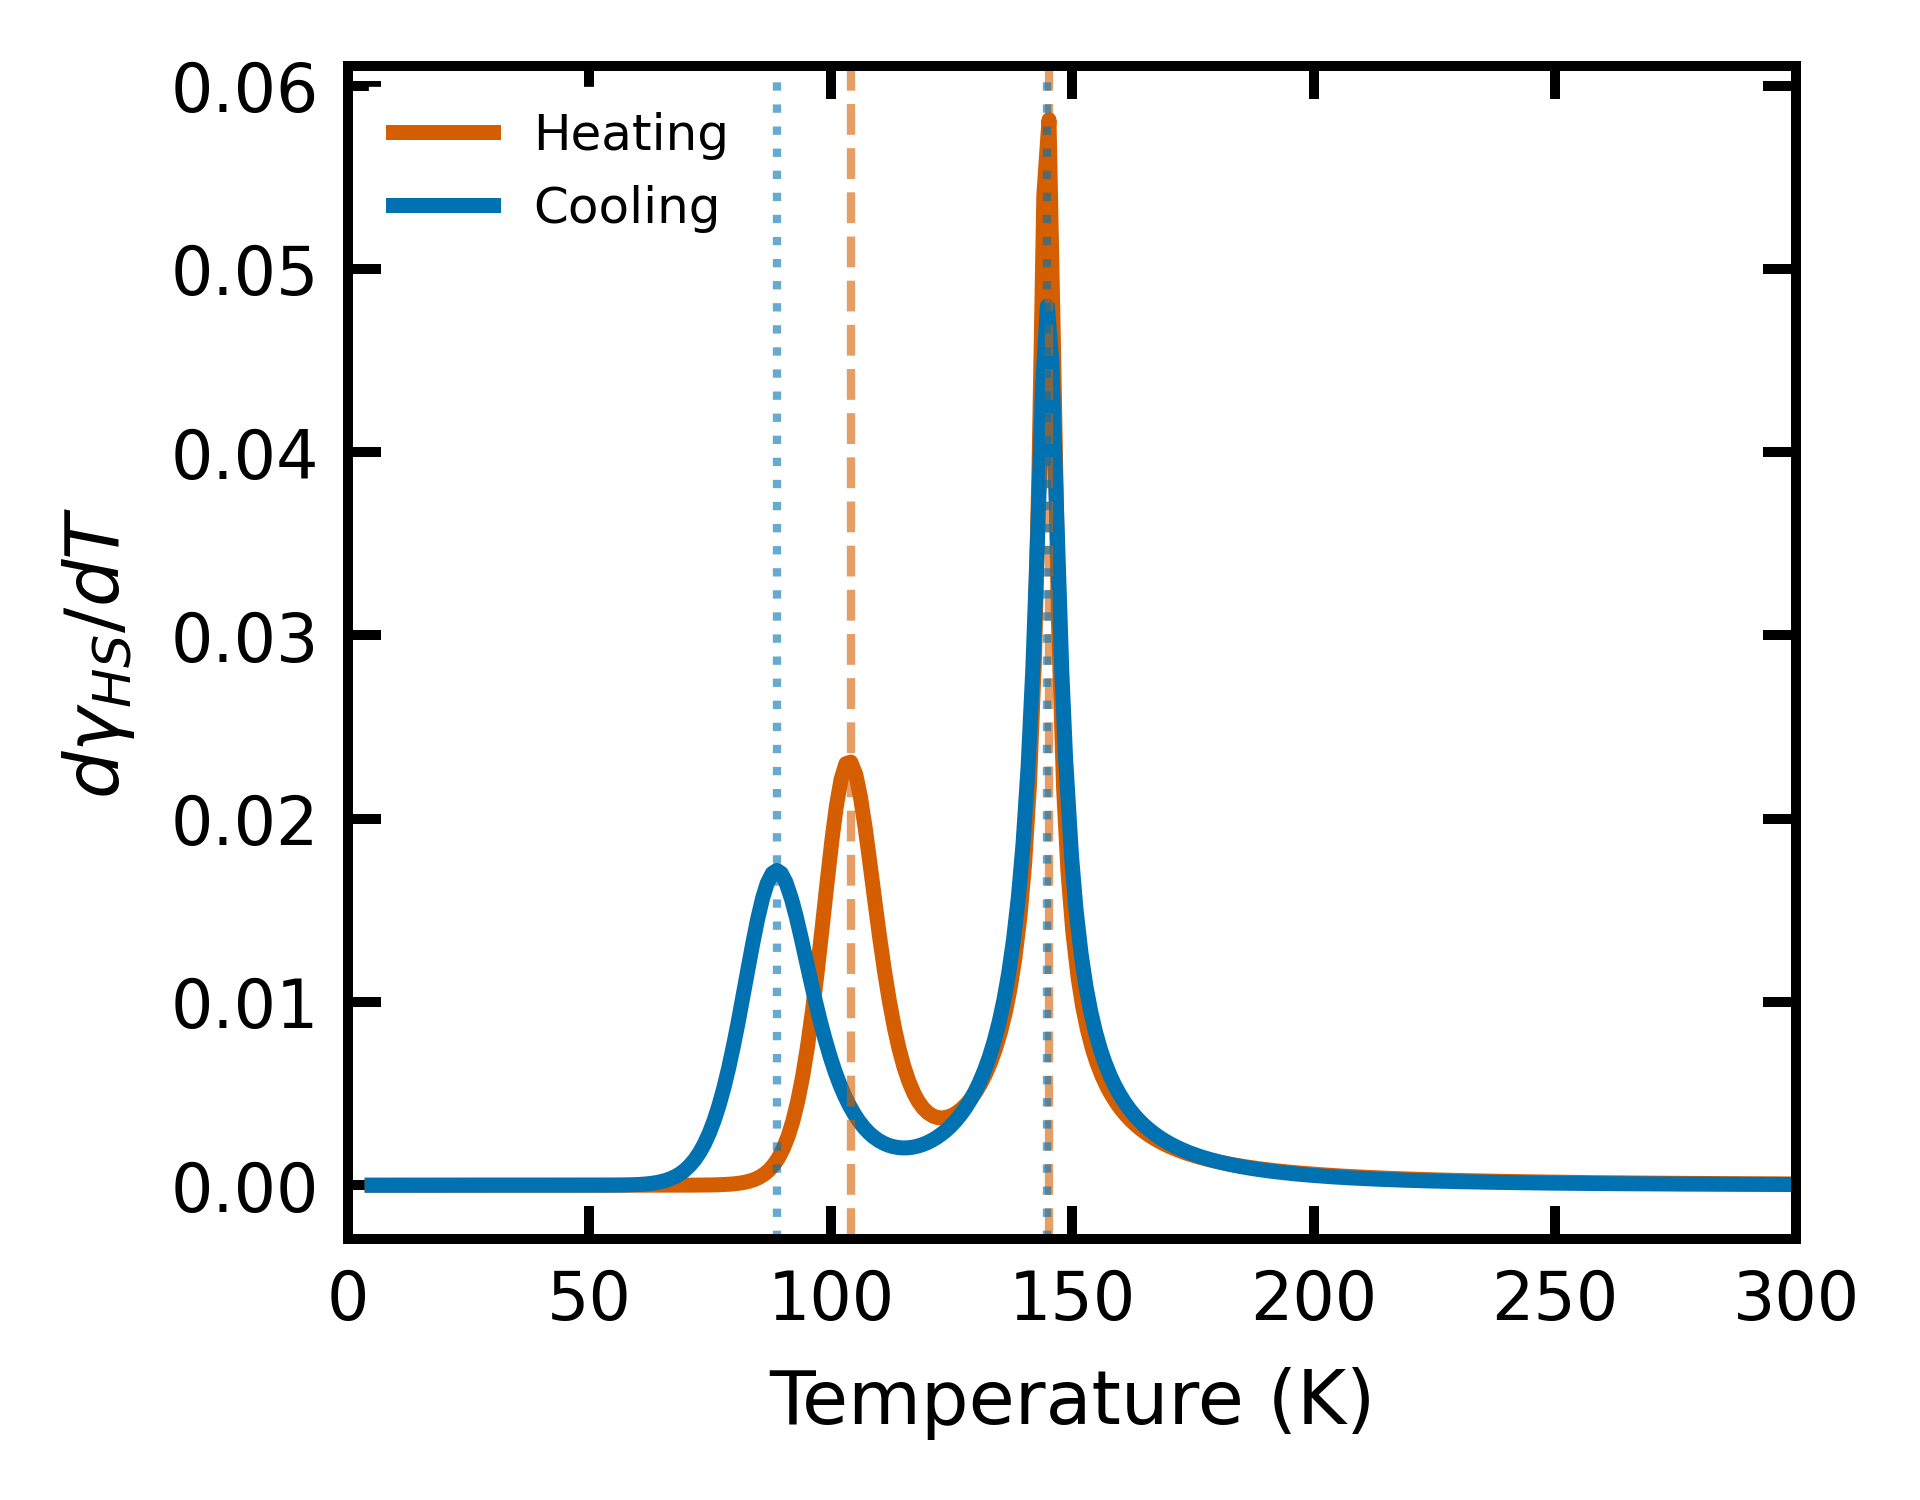

In [30]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(3.3, 2.6), dpi=600)
ax = plt.gca()

ax.plot(T_heat, dg_heat, color='#D55E00', lw=1.8, label='Heating')
ax.plot(T_cool, dg_cool, color='#0072B2', lw=1.8, label='Cooling')

for tc in Tcs_heat:
    ax.axvline(tc, ls='--', lw=1.0, color='#D55E00', alpha=0.6)

for tc in Tcs_cool:
    ax.axvline(tc, ls=':', lw=1.0, color='#0072B2', alpha=0.6)

ax.set_xlabel("Temperature (K)", fontsize=9)
ax.set_ylabel(r"$d\gamma_{HS}/dT$", fontsize=9)

# Fixed x-axis scale and 50 K interval ticks
ax.set_xlim(0, 300)
ax.set_xticks(np.arange(0, 301, 50))

ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=4,
    width=1.2,
    labelsize=8,
    top=True,
    right=True
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=2,
    width=1.0,
    top=False,
    right=False
)

#ax.minorticks_on()

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.legend(
    fontsize=6,
    loc='upper left',
    frameon=True,
    edgecolor='white',
    fancybox=False,
    framealpha=1.0
)

plt.tight_layout()
plt.savefig("figure1.tiff", dpi=600, bbox_inches='tight')
plt.savefig("figure1.png", dpi=600, bbox_inches='tight')
plt.show()

In [19]:
# =========================
# PARAMETER SUMMARY TABLE
# =========================
def make_param_table(params, branch_name="Heating"):
    dH1, dS1, G1, dH2, dS2, G2, w, chiLS0, beta, chiHS0, alpha = params

    out = pd.DataFrame({
        "Branch": [branch_name, branch_name],
        "Step": [1, 2],
        "dH (J/mol)": [dH1, dH2],
        "dS (J/mol/K)": [dS1, dS2],
        "Gamma (J/mol)": [G1, G2],
        "T_half_ideal (K)": [dH1/dS1 if dS1 != 0 else np.nan,
                             dH2/dS2 if dS2 != 0 else np.nan]
    })
    return out

table_heat = make_param_table(params_heat, "Heating")
table_cool = make_param_table(params_cool, "Cooling")

summary_table = pd.concat([table_heat, table_cool], ignore_index=True)
print(summary_table)

    Branch  Step    dH (J/mol)  dS (J/mol/K)  Gamma (J/mol)  T_half_ideal (K)
0  Heating     1   8169.696667     56.321278    2131.781725        145.055244
1  Heating     2  22312.973389    213.997697      57.523904        104.267353
2  Cooling     1  10511.790415     72.380925    1935.337986        145.228738
3  Cooling     2  12033.952338    133.841950     117.582623         89.911663


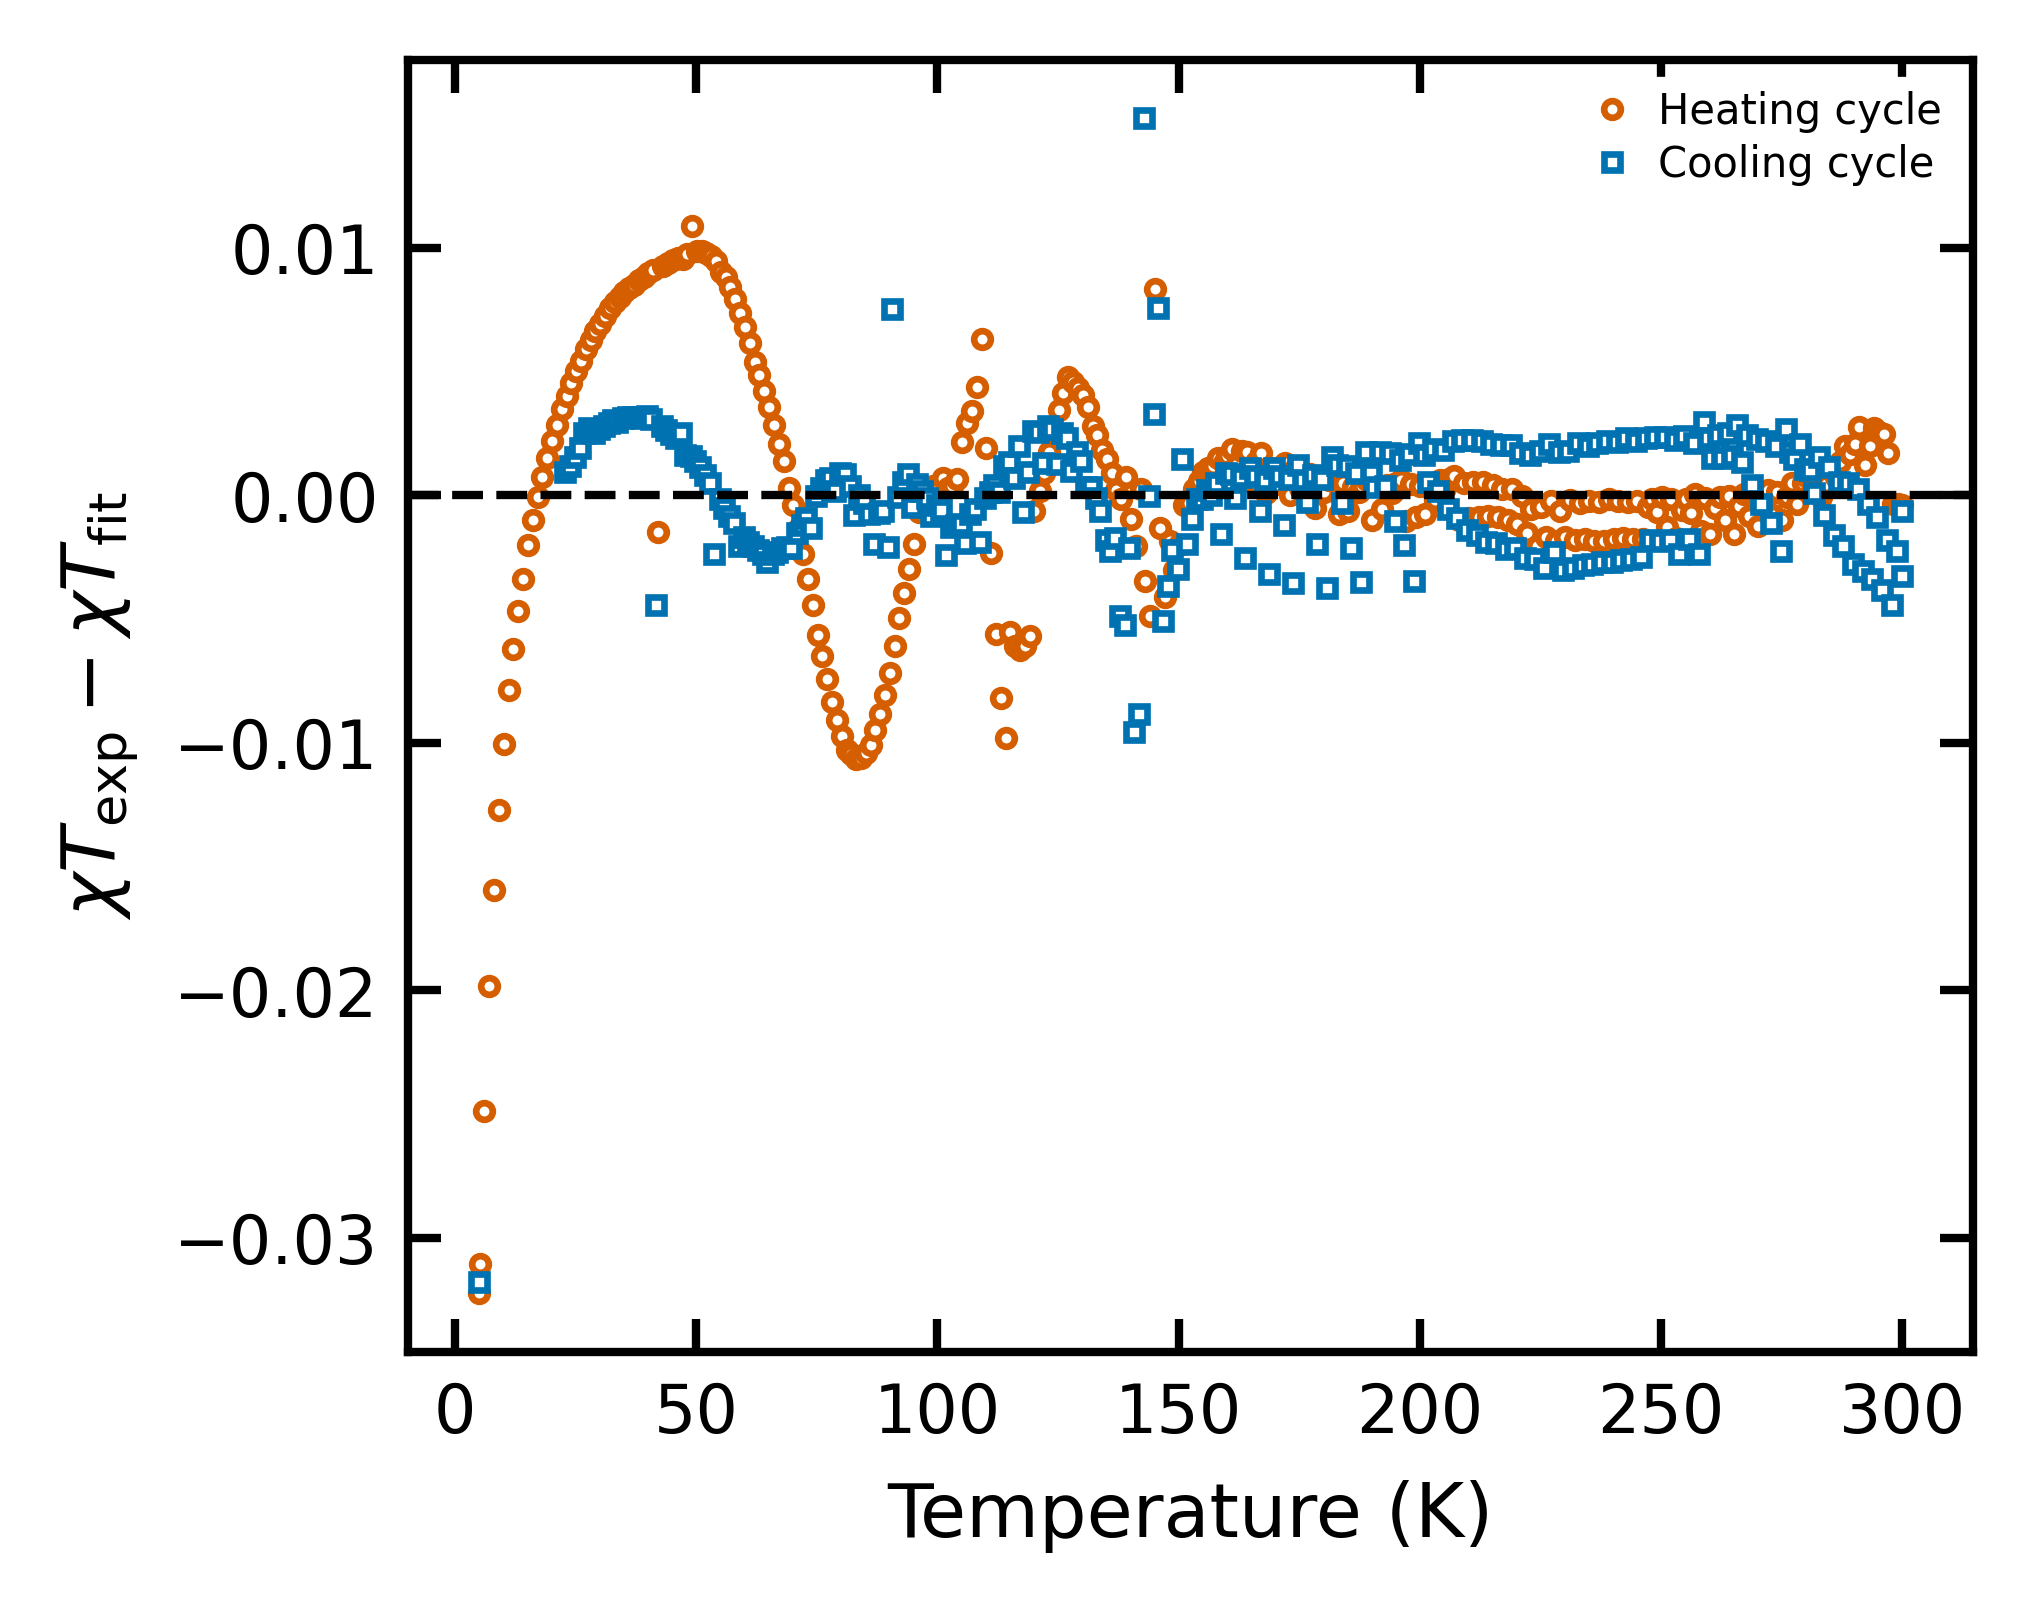

In [20]:
# =========================
# PUBLICATION-QUALITY RESIDUAL PLOT (JPCC-TIGHTENED)
# =========================
fig, ax = plt.subplots(figsize=(3.3, 2.6), dpi=600)

# Heating residuals
ax.plot(
    T_heat, res_heat,
    linestyle='None',
    marker='o',
    markersize=2,
    markerfacecolor='white',
    markeredgewidth=0.8,
    color='#D55E00',
    label='Heating cycle'
)

# Cooling residuals
ax.plot(
    T_cool, res_cool,
    linestyle='None',
    marker='s',
    markersize=2,
    markerfacecolor='white',
    markeredgewidth=0.8,
    color='#0072B2',
    label='Cooling cycle'
)

# Zero reference line
ax.axhline(
    0,
    color='black',
    linewidth=1.0,
    linestyle='--'
)

# Axis labels
ax.set_xlabel("Temperature (K)", fontsize=9)
ax.set_ylabel(r'$\chi T_{\mathrm{exp}} - \chi T_{\mathrm{fit}}$', fontsize=9)

# Major ticks (all sides)
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=4,
    width=1.0,
    labelsize=8,
    top=True,
    right=True
)

# Minor ticks (bottom + left only)
ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=2,
    width=0.8,
    top=False,
    right=False
)
# ax.minorticks_on()

# Spine styling
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Legend (compact JPCC style)
ax.legend(
    fontsize=5,
    loc='upper right',
    frameon=True,
    edgecolor='white',
    fancybox=False,
    framealpha=1.0,
    borderpad=0.25,
    handlelength=1.4,
    handletextpad=0.4,
    labelspacing=0.25
)

# Tight layout
plt.tight_layout(pad=0.4)

# Save
plt.savefig("Residuals_publishable.png", dpi=600, bbox_inches='tight')
plt.savefig("Residuals_publishable.tiff", dpi=600, bbox_inches='tight')

plt.show()

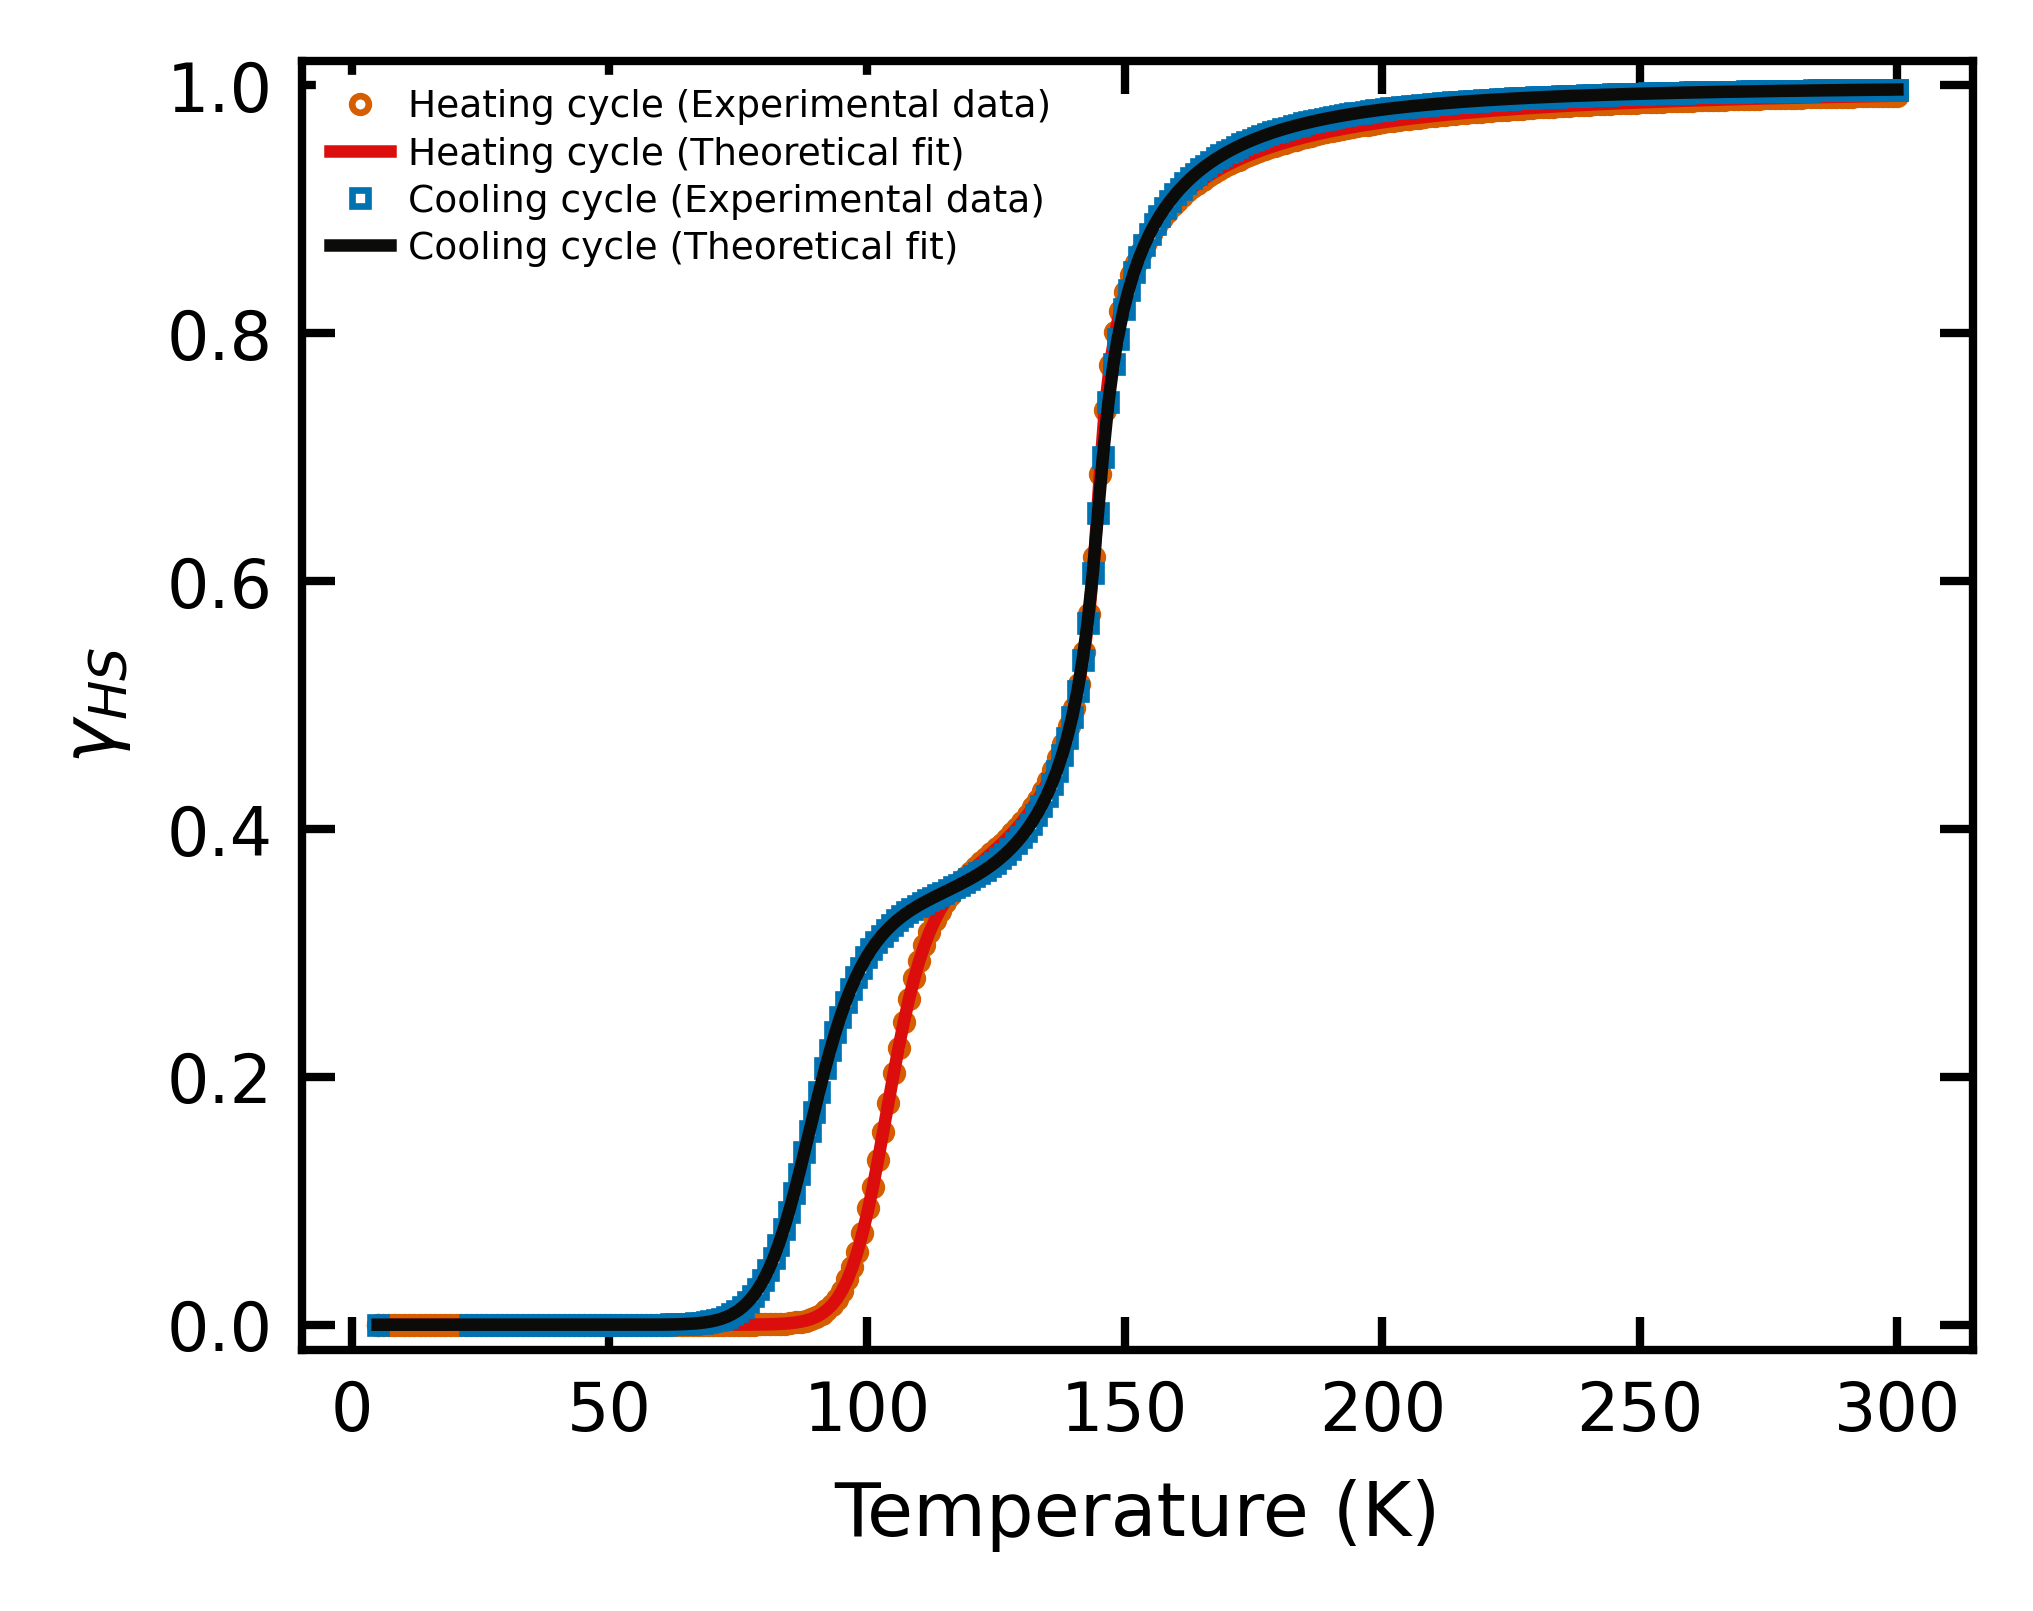

In [21]:
# =========================
# PUBLICATION-QUALITY TOTAL HS FRACTION PLOT (JPCC-TIGHTENED)
# =========================
fig, ax = plt.subplots(figsize=(3.3, 2.6), dpi=600)

# Heating experimental
ax.plot(
    T_heat, gamma_heat,
    linestyle='None',
    marker='o',
    markersize=2,
    markerfacecolor='white',
    markeredgewidth=0.8,
    linewidth=1.6,
    color='#D55E00',
    label='Heating cycle (Experimental data)'
)

# Heating fit
ax.plot(
    T_heat, gamma_heat,
    linestyle='-',
    linewidth=1.5,
    color="#DB0D0DFF",
    label='Heating cycle (Theoretical fit)'
)

# Cooling experimental
ax.plot(
    T_cool, gamma_cool,
    linestyle='None',
    marker='s',
    markersize=2,
    markerfacecolor='white',
    markeredgewidth=0.8,
    linewidth=1.6,
    color='#0072B2',
    label='Cooling cycle (Experimental data)'
)

# Cooling fit
ax.plot(
    T_cool, gamma_cool,
    linestyle='-',
    linewidth=1.5,
    color="#0B0B0A",
    label='Cooling cycle (Theoretical fit)'
)

ax.set_xlabel("Temperature (K)", fontsize=9)
ax.set_ylabel(r'$\gamma_{HS}$', fontsize=9)
# ax.set_title("Two-step SD-derived total HS fractions", fontsize=15, fontweight='bold', pad=10)

# Major ticks: all sides
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=4,
    width=1.0,
    labelsize=8,
    top=True,
    right=True
)

# Minor ticks: bottom and left only
ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=2,
    width=0.8,
    top=False,
    right=False
)
#ax.minorticks_on()

for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')


ax.legend(
    fontsize=4.5,
    loc='upper left',          # keep at top-right
    frameon=True,
    edgecolor='white',
    fancybox=False,
    framealpha=1.0,
    borderpad=0.25,
    handlelength=1.6,
    handletextpad=0.5,
    labelspacing=0.3
)

ax.set_ylim(-0.02, 1.02)

plt.tight_layout(pad=0.4)
plt.savefig("Total_HS_fraction_fit_publishable.png", dpi=600, bbox_inches='tight')
plt.savefig("Total_HS_fraction_fit_publishable.tiff", dpi=600, bbox_inches='tight')
plt.show()

In [22]:
# =========================
# SINGLE STEP SD MODEL
# =========================

def single_step_sd_model(T, params):

    dH, dS, G, chiLS0, beta, chiHS0, alpha = params

    gamma = solve_sd_fraction(T, dH, dS, G, gamma0=0.5)

    chi_ls_T = chiLS0 + beta*T
    chi_hs_T = chiHS0 + alpha*T

    chiT_calc = (1-gamma)*chi_ls_T + gamma*chi_hs_T

    return chiT_calc


def residuals_single(params, T, chiT_exp):

    chiT_calc = single_step_sd_model(T, params)

    return chiT_calc - chiT_exp

In [23]:
# =========================
# SINGLE STEP FIT
# =========================

p0_single = [
    15000, 100, 1000,
    chiLS_heat, 0,
    chiHS_heat, 0
]

fit_single = least_squares(
    residuals_single,
    p0_single,
    args=(T_heat, chiT_heat),
    max_nfev=3000
)

params_single = fit_single.x

chiT_single = single_step_sd_model(T_heat, params_single)

In [24]:
# =========================
# RESIDUAL SUM OF SQUARES
# =========================

rss_single = np.sum((chiT_heat - chiT_single)**2)
rss_two = np.sum((chiT_heat - chiT_fit_heat)**2)

n = len(T_heat)

k_single = 7
k_two = 11

In [25]:
# =========================
# AIC MODEL COMPARISON
# =========================

AIC_single = n*np.log(rss_single/n) + 2*k_single
AIC_two = n*np.log(rss_two/n) + 2*k_two

print("===== MODEL COMPARISON =====")

print("Single-step SD AIC =", AIC_single)
print("Two-step SD AIC    =", AIC_two)

print("ΔAIC =", AIC_single - AIC_two)

===== MODEL COMPARISON =====
Single-step SD AIC = -2334.115749205608
Two-step SD AIC    = -3076.0406836847005
ΔAIC = 741.9249344790924


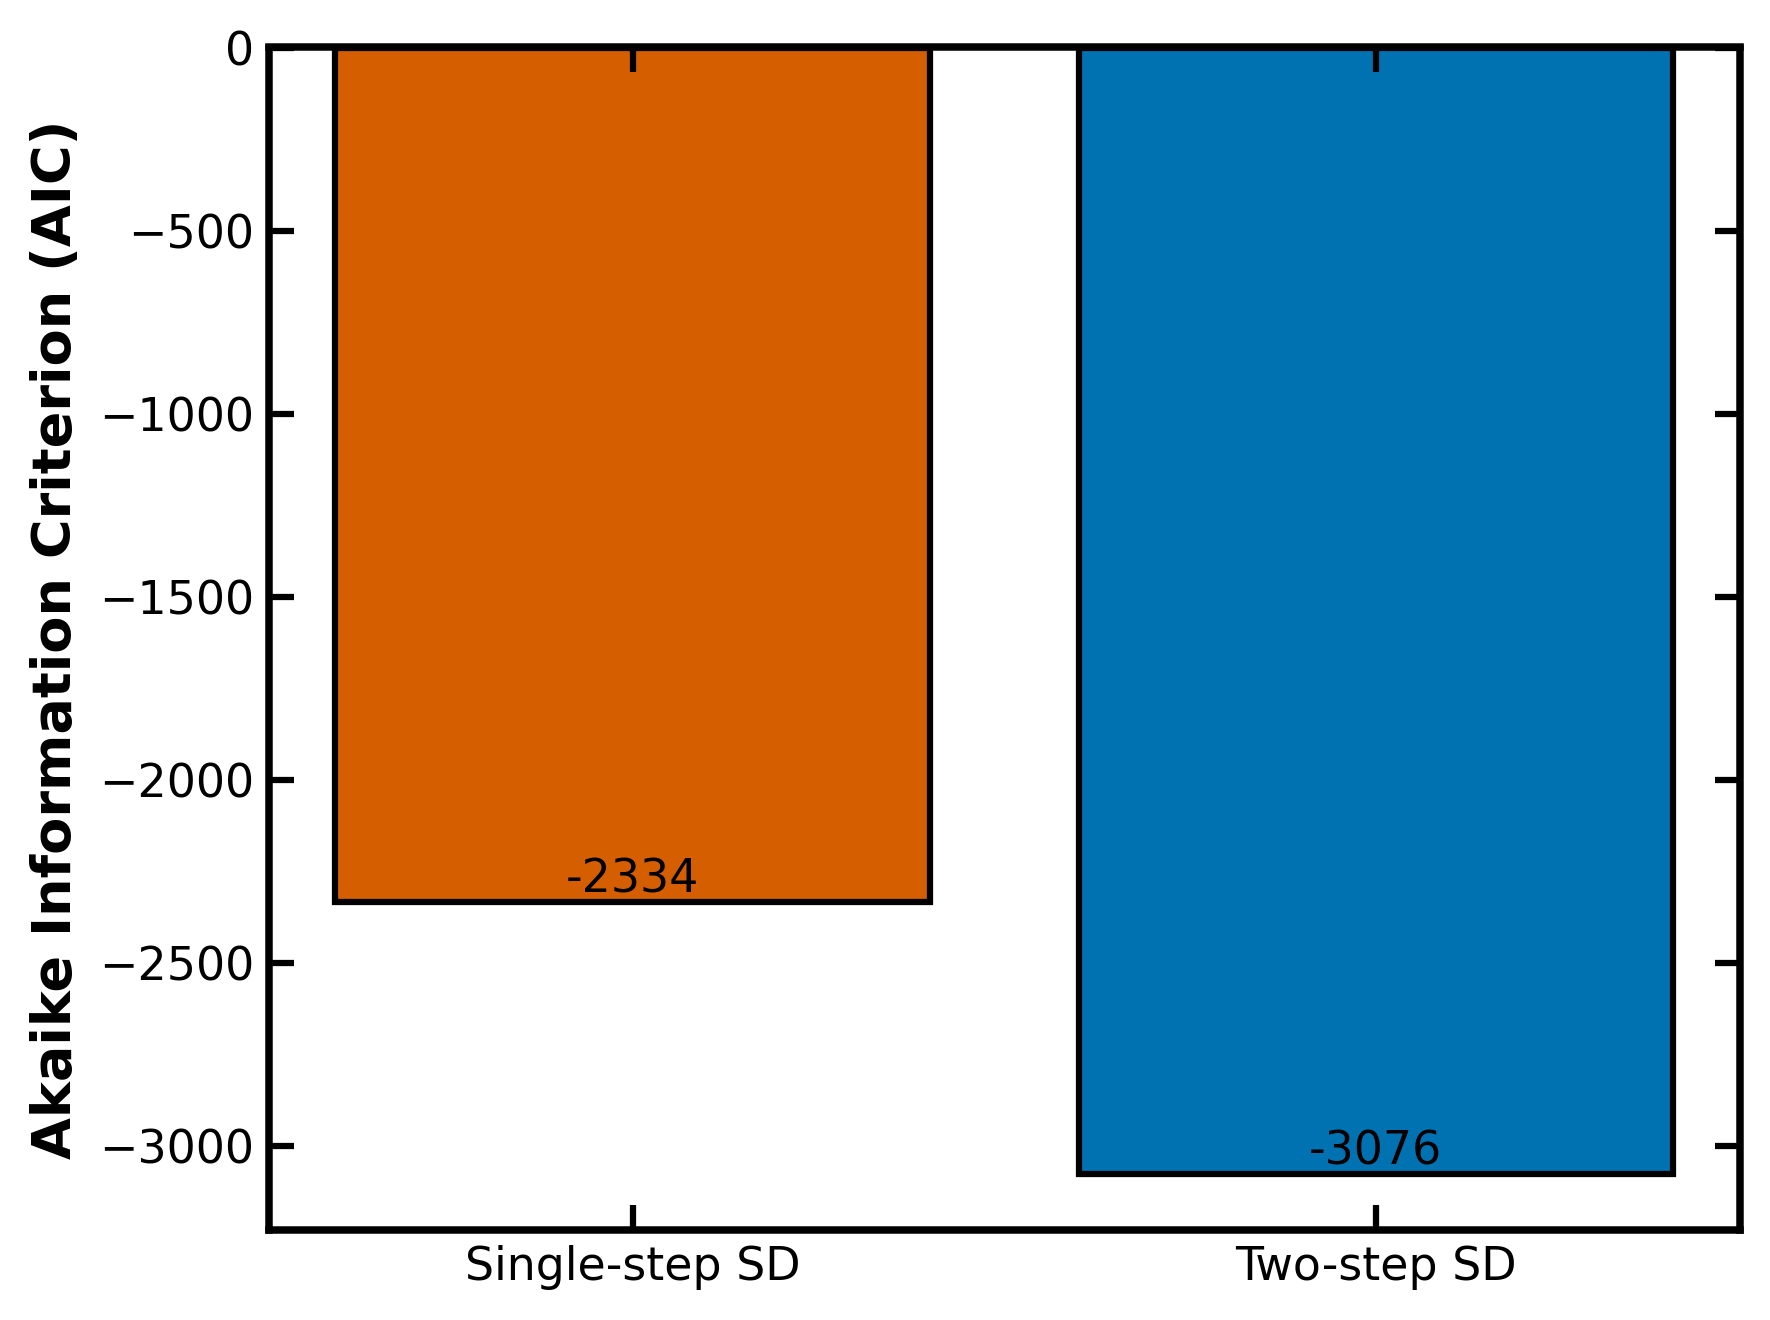

In [26]:
# =========================
# AIC COMPARISON PLOT
# =========================

import matplotlib.pyplot as plt
import numpy as np

models = ["Single-step SD", "Two-step SD"]
AIC_values = [AIC_single, AIC_two]

fig, ax = plt.subplots(figsize=(6,4.5), dpi=300)

bars = ax.bar(
    models,
    AIC_values,
    color=["#D55E00", "#0072B2"],
    edgecolor="black",
    linewidth=1.5
)

# Labels
ax.set_ylabel("Akaike Information Criterion (AIC)", fontsize=13, fontweight="bold")

# Tick styling
ax.tick_params(
    axis='both',
    direction='in',
    length=6,
    width=1.5,
    labelsize=11,
    top=True,
    right=True
)

# Bold border
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.0f}",
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()

plt.savefig("AIC_model_comparison.png", dpi=600, bbox_inches="tight")
plt.savefig("AIC_model_comparison.tiff", dpi=600, bbox_inches="tight")

plt.show()